In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

df = pd.read_csv('../data/processed/merged_day1.csv')

sns.set_style('whitegrid')
df.shape

(36457, 19)

### Separate numerical and categorical columns

In [6]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove ID and TARGET from the feature lists
num_cols = [c for c in num_cols if c not in ['ID', 'TARGET']]

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS']
Categorical: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


/var/folders/1y/j10mjg4j427fhhtbl9b69npw0000gn/T/ipykernel_33706/4072426791.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


### Distribution of numerical features

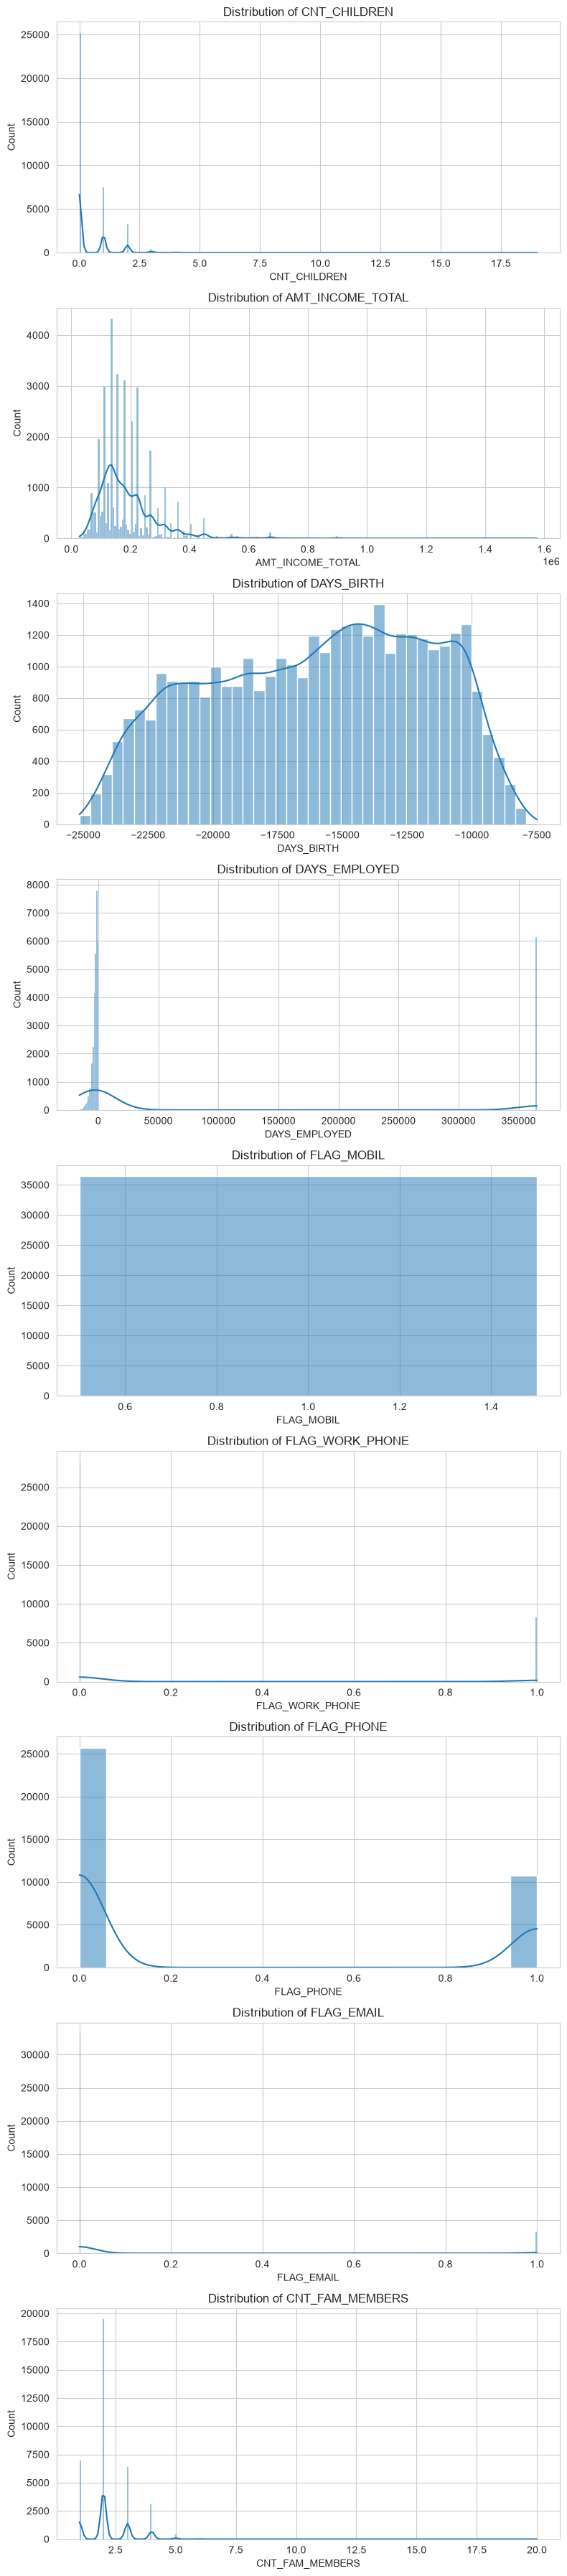

In [11]:
fig, axes = plt.subplots(nrows=len(num_cols), ncols=1, figsize=(8, 4*len(num_cols)))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### Categorical feature frequency

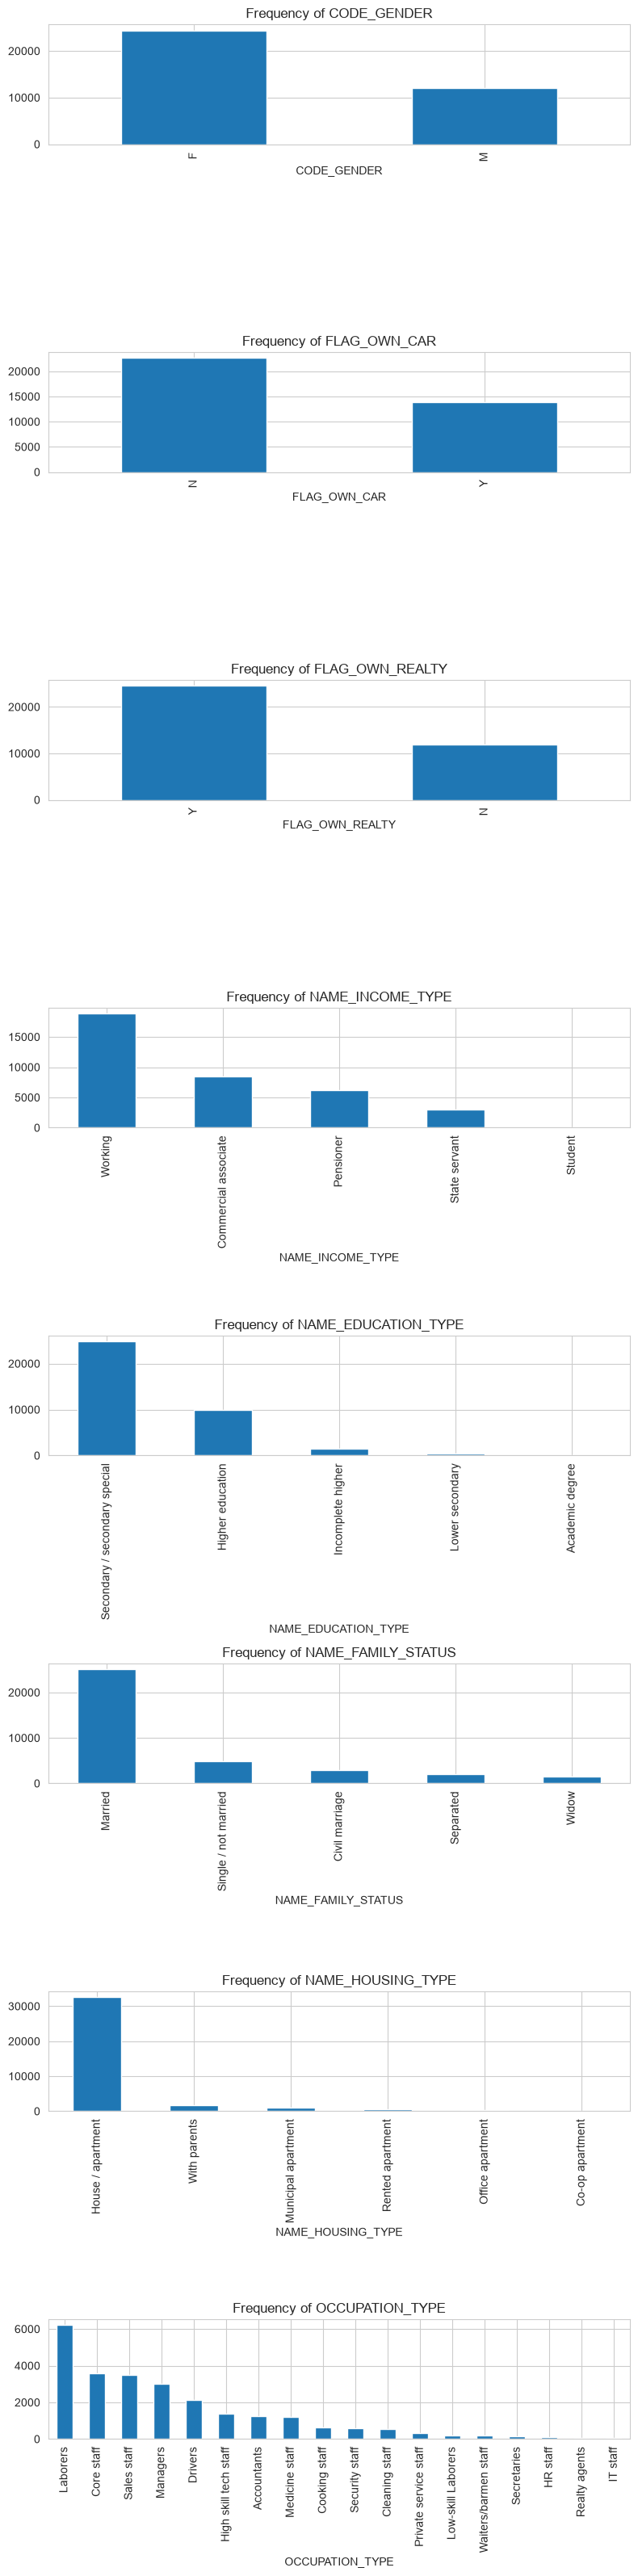

In [16]:
fig, axes = plt.subplots(nrows=len(cat_cols), ncols=1, figsize=(8, 4*len(cat_cols)))
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Frequency of {col}')
plt.tight_layout()
plt.show()

### Target Relationship - numerical features vs TARGET

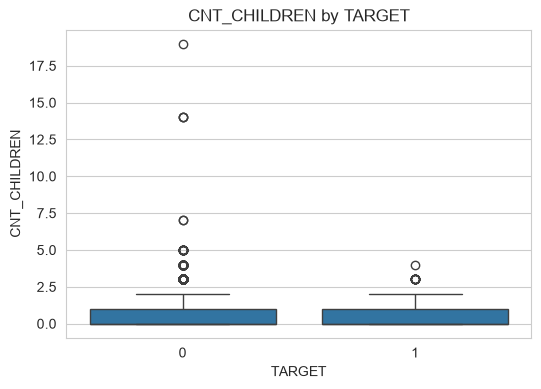

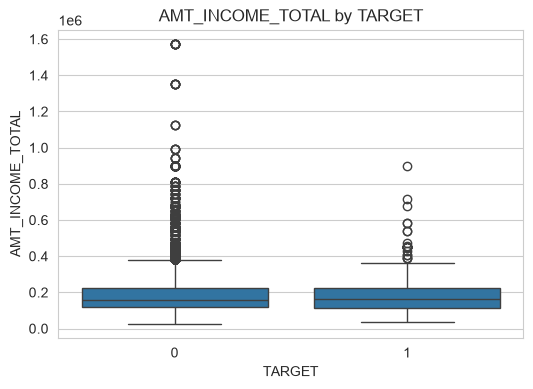

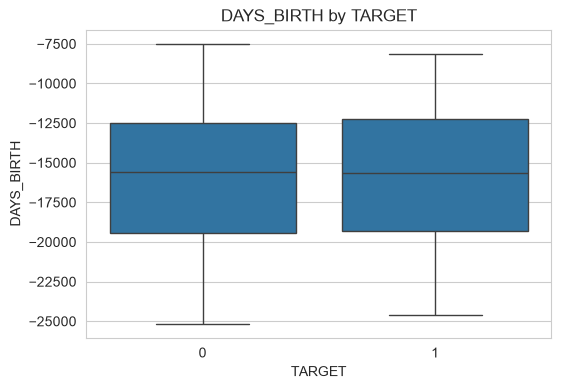

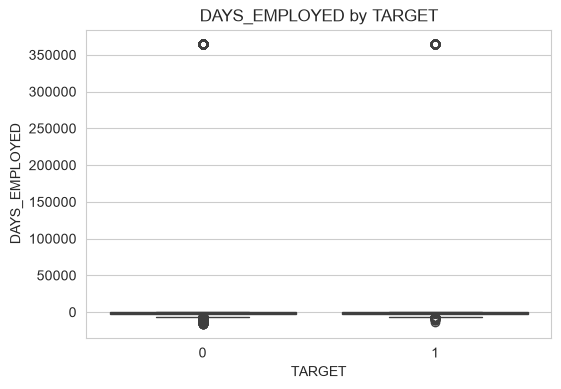

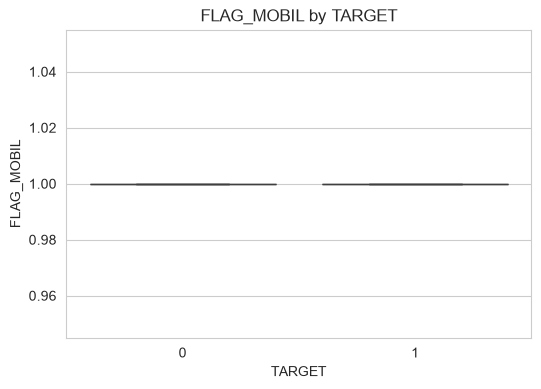

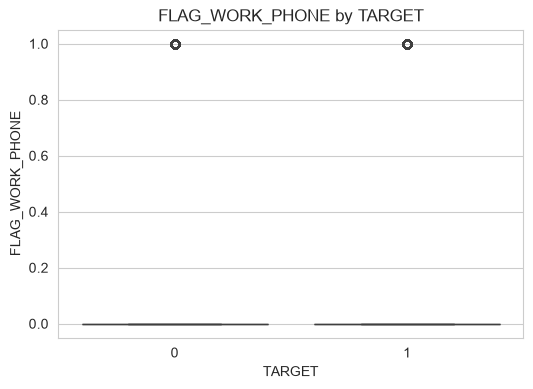

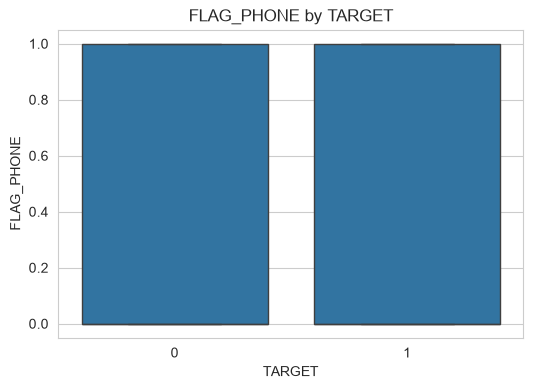

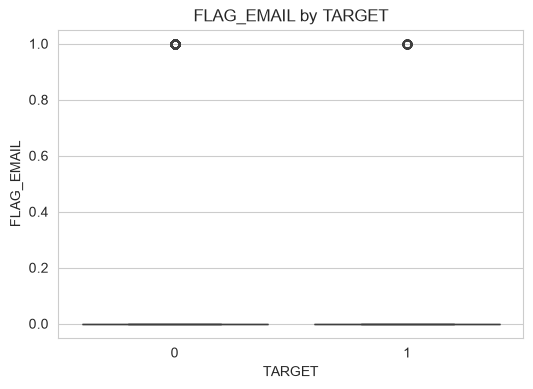

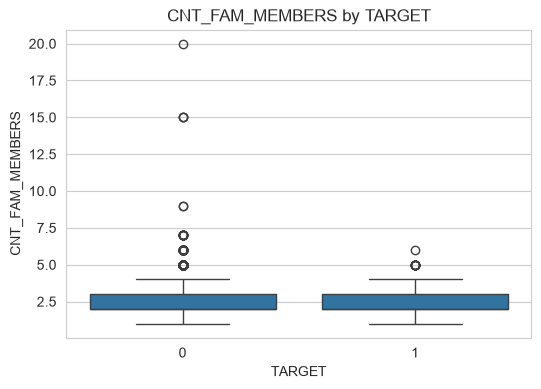

In [19]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='TARGET', y=col, data=df)
    plt.title(f'{col} by TARGET')
    plt.show()

In [22]:
df.groupby('TARGET')[num_cols].mean()

,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
TARGET,,,,,,,,,
0,0.430345,186699.846740,-15975.987500,59160.728691,1.0,0.225217,0.294718,0.089813,2.199129
1,0.428571,185864.763799,-15927.805195,65209.683442,1.0,0.243506,0.300325,0.084416,2.159091


### Target relationship - Categorical features vs TARGET

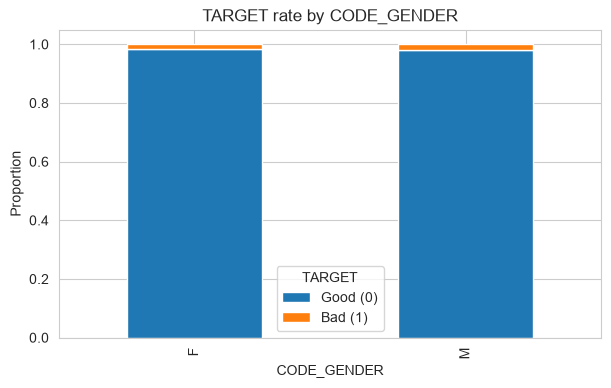

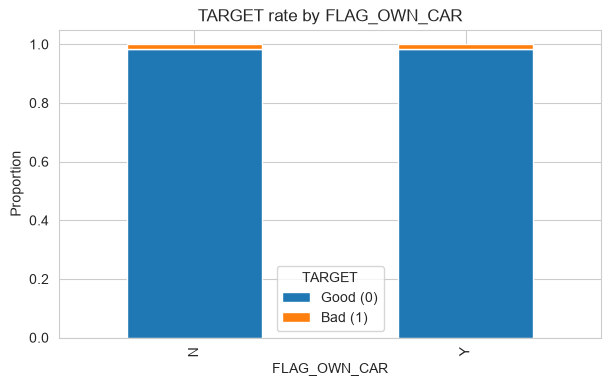

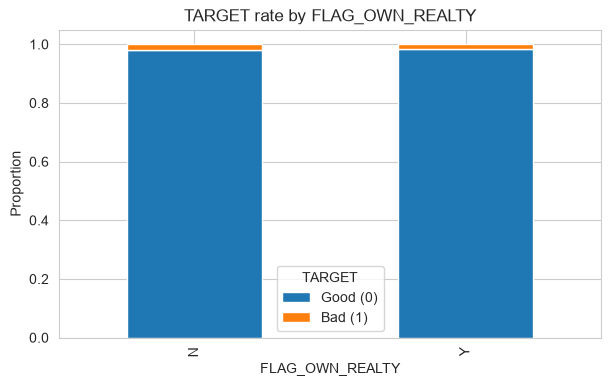

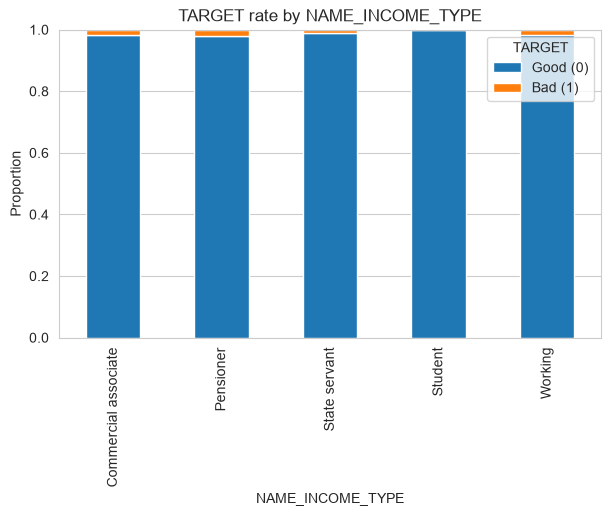

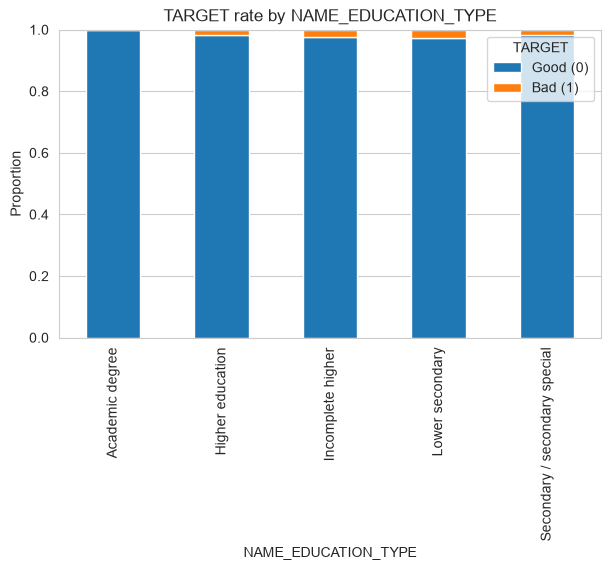

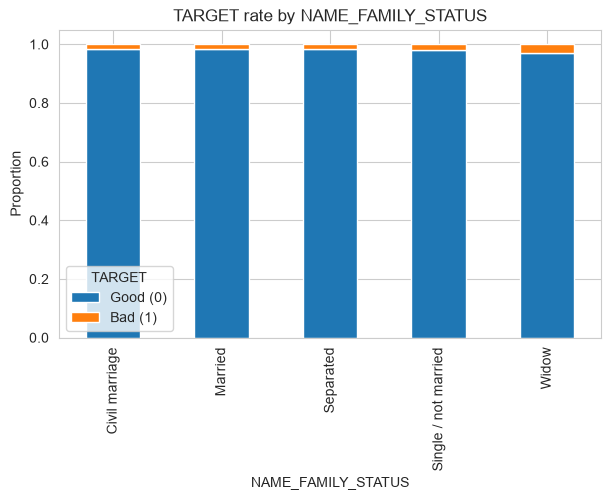

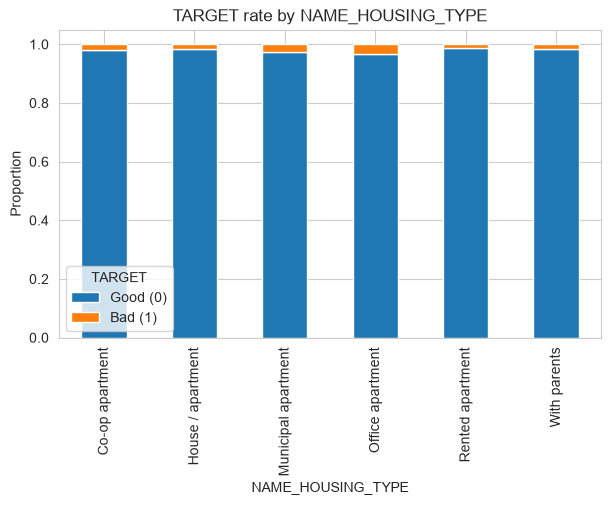

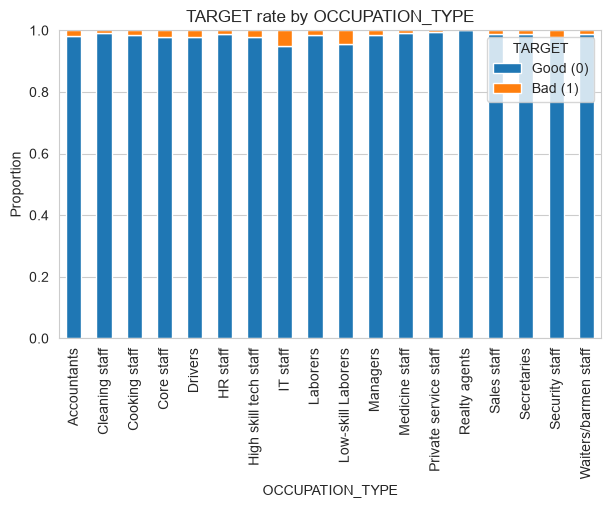

In [25]:
for col in cat_cols:
    ct = pd.crosstab(df[col], df['TARGET'], normalize='index')
    ct.plot(kind='bar', stacked=True, figsize=(7, 4))
    plt.title(f'TARGET rate by {col}')
    plt.ylabel('Proportion')
    plt.legend(title='TARGET', labels=['Good (0)', 'Bad (1)'])
    plt.show()

### Correlation heatmap (numerical features)

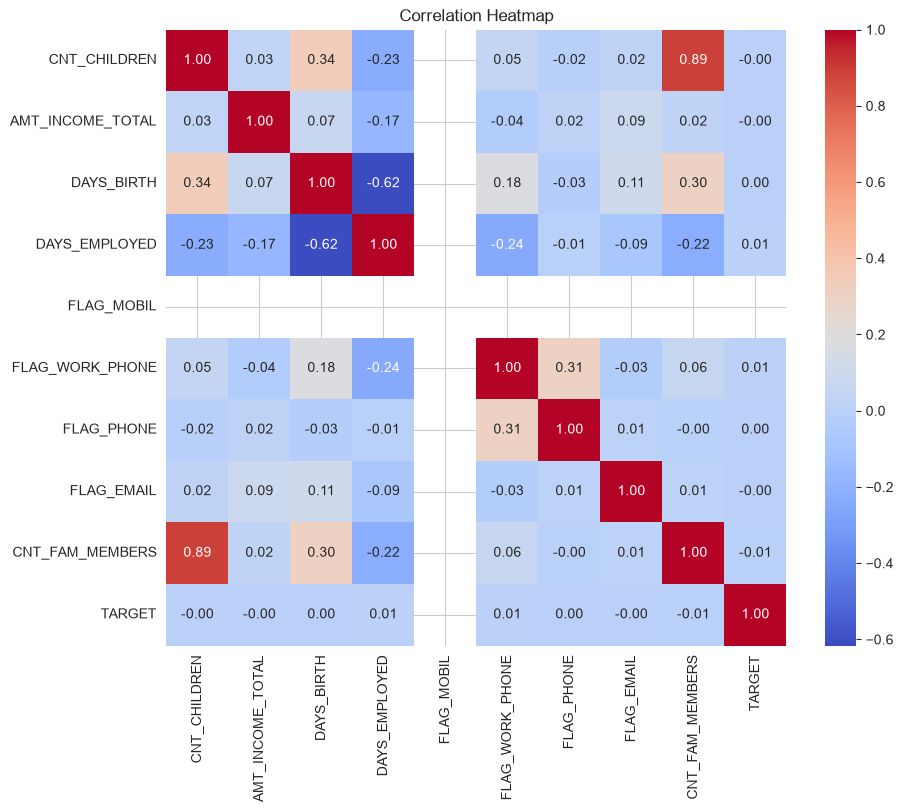

In [28]:
plt.figure(figsize=(10, 8))
corr = df[num_cols + ['TARGET']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Age and employment duration

In [31]:
# DAYS_BIRTH is negative days from today; convert to age in years
df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365).round(1)

# DAYS_EMPLOYED often has a placeholder (365243) for unemployed/pensioners
print("Max DAYS_EMPLOYED:", df['DAYS_EMPLOYED'].max())
print("Count of placeholder value:", (df['DAYS_EMPLOYED'] == 365243).sum())

Max DAYS_EMPLOYED: 365243
Count of placeholder value: 6135


## Findings Summary
1. Features that are most predictive of TARGET are categorical features like NAME_INCOME_TYPE, NAME_FAMILY_STATUS, and OCCUPATION_TYPE
2. Data Quality Issues:
   - DAYS_EMPLOYED contains a placeholder value of 365243, appearing 6,531 times -> likely represents the unemployed/pensioner applicants rather than a real employment duration and should be handled before modeling
   - AMT_INCOME_TOTAL is strongly right-skewed and contains many high-value outliers.
   - CNT_CHILDREN and CNT_FAM_MEMBERS also contain some unusually high values/outliers.
   - The binary flag variables (FLAG_MOBIL, FLAG_WORK_PHONE, FLAG_PHONE, FLAG_EMAIL) have very limited variation, so some may provide little predictive information.